# 05 — 1D CNN

Standalone notebook. Run `00_Preprocessing.ipynb` first. Each feature
is treated as one timestep with 1 channel (standard tabular→sequence
framing for CNN/RNN architectures on flow-based IDS data).

In [1]:
import os, time
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from utils import PROCESSED_DIR, RESULTS_DIR, MODELS_DIR, PLOTS_DIR, evaluate, save_results

SEED = 42
tf.random.set_seed(SEED)
MODEL_NAME = "1D CNN"
DL_EPOCHS = 20
DL_BATCH_SIZE = 256


## Load Preprocessed Data

In [2]:
X_train_res = np.load(os.path.join(PROCESSED_DIR, "X_train_res.npy"))
y_train_res = np.load(os.path.join(PROCESSED_DIR, "y_train_res.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
class_names = joblib.load(os.path.join(PROCESSED_DIR, "class_names.joblib"))
n_classes = joblib.load(os.path.join(PROCESSED_DIR, "n_classes.joblib"))

X_train_res_seq = X_train_res.reshape((X_train_res.shape[0], X_train_res.shape[1], 1))
X_test_seq = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(f"Train: {X_train_res_seq.shape}, Test: {X_test_seq.shape}, classes: {n_classes}")


Train: (911664, 78, 1), Test: (53582, 78, 1), classes: 15


## Build & Train

In [3]:
def build_cnn1d(n_features, n_classes):
    model = models.Sequential([
        layers.Input(shape=(n_features, 1)),
        layers.Conv1D(64, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


model = build_cnn1d(X_train_res.shape[1], n_classes)
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

t0 = time.time()
history = model.fit(
    X_train_res_seq, y_train_res, validation_split=0.1,
    epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
    callbacks=[early_stop], verbose=2,
)
train_time = time.time() - t0
print(f"Train time: {train_time:.2f}s")


Epoch 1/20
3206/3206 - 58s - 18ms/step - accuracy: 0.7701 - loss: 0.7131 - val_accuracy: 0.3517 - val_loss: 6.5260
Epoch 2/20
3206/3206 - 50s - 16ms/step - accuracy: 0.9121 - loss: 0.2807 - val_accuracy: 0.3931 - val_loss: 6.1818
Epoch 3/20
3206/3206 - 46s - 14ms/step - accuracy: 0.9326 - loss: 0.2161 - val_accuracy: 0.4136 - val_loss: 5.7039
Epoch 4/20
3206/3206 - 45s - 14ms/step - accuracy: 0.9436 - loss: 0.1801 - val_accuracy: 0.4135 - val_loss: 5.6018
Epoch 5/20
3206/3206 - 47s - 15ms/step - accuracy: 0.9502 - loss: 0.1592 - val_accuracy: 0.4098 - val_loss: 5.3578
Epoch 6/20
3206/3206 - 47s - 15ms/step - accuracy: 0.9550 - loss: 0.1403 - val_accuracy: 0.4086 - val_loss: 4.7982
Epoch 7/20
3206/3206 - 43s - 13ms/step - accuracy: 0.9567 - loss: 0.1365 - val_accuracy: 0.4093 - val_loss: 5.5703
Epoch 8/20
3206/3206 - 43s - 13ms/step - accuracy: 0.9607 - loss: 0.1213 - val_accuracy: 0.4019 - val_loss: 5.6142
Epoch 9/20
3206/3206 - 44s - 14ms/step - accuracy: 0.9623 - loss: 0.1170 - val_a

## Predict & Evaluate

In [4]:
t0 = time.time()
y_proba = model.predict(X_test_seq, verbose=0)
infer_time = time.time() - t0
y_pred = np.argmax(y_proba, axis=1)

row = evaluate(MODEL_NAME, y_test, y_pred, y_proba, train_time, infer_time, n_classes)
for k, v in row.items():
    if k not in ("Confusion Matrix",):
        print(f"{k}: {v}")


Model: 1D CNN
Accuracy: 0.9109215781419133
Precision: 0.37980971540773145
Recall: 0.7561197801879734
F1-Score: 0.43755764841030853
ROC-AUC: nan
MCC: 0.780499208975085
Cohen's Kappa: 0.7654729265986157
Train Time (s): 424.80336022377014
Prediction Time (s): 3.779996633529663


## Training Curves

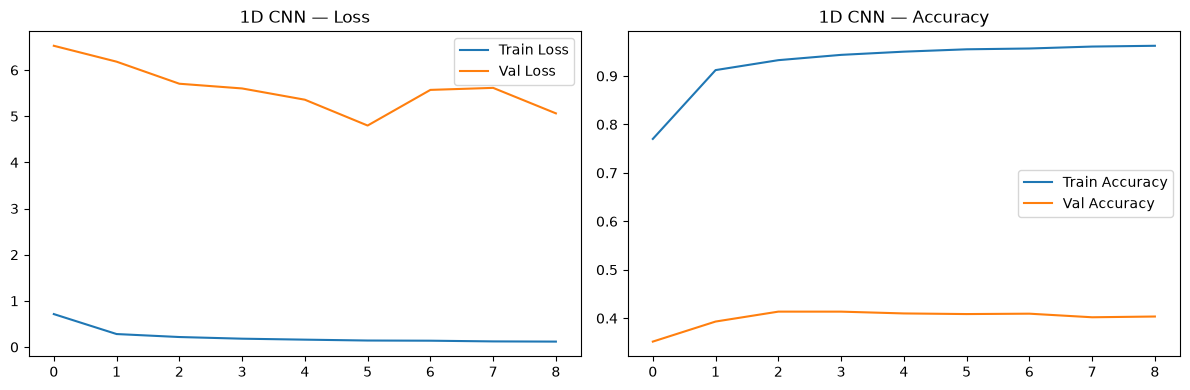

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title(f"{MODEL_NAME} — Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title(f"{MODEL_NAME} — Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "CNN1D_training_curves.png"), dpi=150)
plt.show()


## Confusion Matrix Plot

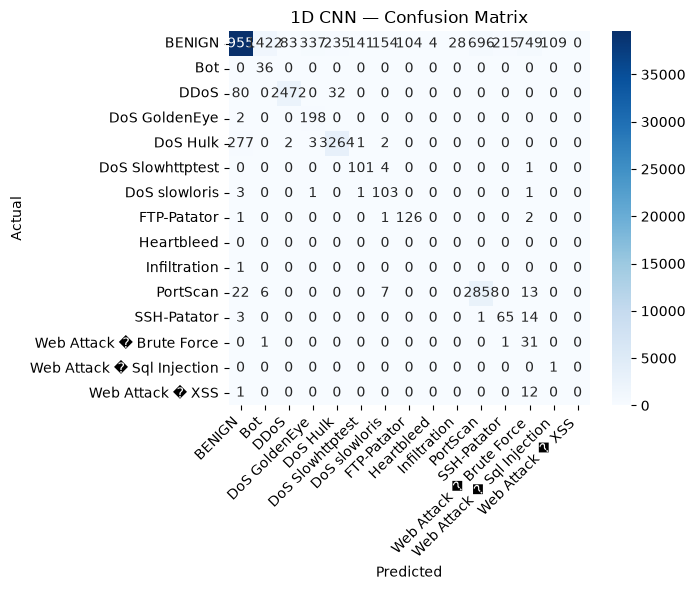

In [6]:
cm = np.array(row["Confusion Matrix"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{MODEL_NAME} — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "CNN1D_confusion_matrix.png"), dpi=150)
plt.show()


## Save Results & Model

In [7]:
save_results(MODEL_NAME, row, history=history.history)
model.save(os.path.join(MODELS_DIR, "CNN1D.keras"))
print("Saved model and results for", MODEL_NAME)


Saved results to results\1D_CNN_results.json
Saved model and results for 1D CNN
